# EfficientNetB2 para clasificacion de aves CUB-200-2011


## 1. Importar librerias y configurar parametros


In [11]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.efficientnet import EfficientNetB2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
DATASET_NAME = "caltech_birds2011"
IMG_SIZE = 260
BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 5e-4
DROPOUT_RATE = 0.30


MODO = "augmentation"
USAR_AUGMENTATION = MODO in ("augmentation", "finetuning")
HACER_FINETUNING = MODO == "finetuning"

# Hiperparametros de la fase de fine-tuning (solo se usan si MODO == "finetuning").
FINETUNE_FREEZE_LAYERS = 234  # capas iniciales del base que quedan congeladas (descongela block6+)
FINETUNE_LR = 1e-5            # LR bajo para no desestabilizar los pesos preentrenados
FINETUNE_EPOCHS = 20         # epocas adicionales para la 2da fase

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

#Generacion de rutas para guardar los datasets, resultados y modelos
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "modelos" else Path.cwd()
TFDS_DATA_DIR = PROJECT_ROOT / "dataset"
RESULTS_DIR = PROJECT_ROOT / "resultados"
MODELS_DIR = PROJECT_ROOT / "modelos_guardados"

TFDS_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


print("Modo de experimento:", MODO)
print("Augmentation:", USAR_AUGMENTATION, "| Fine-tuning:", HACER_FINETUNING)
print("Dataset cache:", TFDS_DATA_DIR)


Modo de experimento: augmentation
Augmentation: True | Fine-tuning: False
Dataset cache: /home/felipe_r/proyectos/TP3-CNN/dataset


## 2. Cargar el dataset

Usamos splits directos de TFDS para evitar filtros manuales, indices y `steps_per_epoch`. El split oficial `train` se divide en entrenamiento y validacion; el split oficial `test` queda para evaluacion final.

Aqui definimos en que proporcion dividimos los datos haciendo uso del metodo de `División Fija`


In [12]:
TRAIN_SPLIT = "train[:80%]"
VAL_SPLIT = "train[80%:]"
TEST_SPLIT = "test"
print("Splits:", TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT)

(ds_train_raw, ds_val_raw, ds_test_raw), info = tfds.load(
    DATASET_NAME,
    split=[TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT],
    as_supervised=True,
    with_info=True,
    shuffle_files=False,
    data_dir=str(TFDS_DATA_DIR),
)

num_classes = info.features["label"].num_classes
class_names = info.features["label"].names

print(f"Clases de pajaros: {num_classes}")
print(f"Cantidad de datos para Entrenar: {tf.data.experimental.cardinality(ds_train_raw).numpy()}")
print(f"Cantidad de datos para Validación: {tf.data.experimental.cardinality(ds_val_raw).numpy()}")
print(f"Cantidad de datos para Test: {tf.data.experimental.cardinality(ds_test_raw).numpy()}")

Splits: train[:80%] train[80%:] test
Clases de pajaros: 200
Cantidad de datos para Entrenar: 4795
Cantidad de datos para Validación: 1199
Cantidad de datos para Test: 5794


## 3. Visualizar algunas imagenes del dataset


In [ ]:
plt.figure(figsize=(12, 6))
for i, (imagen, etiqueta) in enumerate(ds_train_raw.take(6)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(imagen)
    plt.title(class_names[int(etiqueta.numpy())], fontsize=9)
    plt.axis("off")
plt.tight_layout()


## 4. Funcion para Graficar entrenamiento y mostrar tabla de valores

In [13]:
def plot_training_history(history):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history_df["accuracy"], label="train")
    axes[0].plot(history_df["val_accuracy"], label="validation")
    axes[0].set_title("Accuracy (Precisión)")
    axes[0].set_xlabel("Epocas")
    axes[0].set_ylabel("Precisión")
    axes[0].legend()

    axes[1].plot(history_df["loss"], label="train")
    axes[1].plot(history_df["val_loss"], label="validation")
    axes[1].set_title("Función de Loss")
    axes[1].set_xlabel("Epocas")
    axes[1].set_ylabel("Error")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return history_df

## 5. Preprocesar datos

CUB tiene imagenes de tamaños variables. Usamos `resize_with_pad` para llevarlas a `260x260` sin deformar la proporcion. EfficientNetB2 espera imagenes en el rango `[0, 255]` y aplica su propia normalizacion dentro del modelo, por lo que no usamos `preprocess_input` (es un no-op): basta con entregar la imagen como `float32` en ese rango.


In [14]:
AUTOTUNE = tf.data.AUTOTUNE


def preprocess_image(imagen, etiqueta):
    """
    Normalizamos las imagenes, las adaptamos a como las pide el modelo y preparamos su etiqueta.

    Args:
        imagen: Tensor con la imagen original de CUB-200-2011.
        etiqueta: Indice entero de la clase.

    Returns:
        tuple: Imagen preprocesada y etiqueta entera.
    """

    imagen = tf.image.resize_with_pad(imagen, IMG_SIZE, IMG_SIZE)
    imagen = tf.cast(imagen, tf.float32)
    etiqueta = tf.cast(etiqueta, tf.int32)
    return imagen, etiqueta


def prepare_dataset(dataset, training=False):
    """

    Aplica el preprocesamiento a todos los conjuntos del dataset. Si se indica entrenamiento, 
    mezcla los ejemplos antes de agruparlos en batches. 
    Prefetch prepara un batch y lo manda a entrenar, en paralelo prepara el siguiente Batch.

    Args:
        dataset: Dataset de TensorFlow con pares (imagen, etiqueta).
        training: Si es True, aplica shuffle para entrenamiento.

    Returns:
        tf.data.Dataset: Dataset listo para ser consumido por model.fit o model.evaluate.
    """

    dataset = dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    if training:
        dataset = dataset.shuffle(1024, seed=SEED, reshuffle_each_iteration=True)
        
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = prepare_dataset(ds_train_raw, training=True)
val_ds = prepare_dataset(ds_val_raw)
test_ds = prepare_dataset(ds_test_raw)

for images, labels in train_ds.take(1):
    print("Batch de imagenes:", images.shape)
    print("Batch de etiquetas:", labels.shape)
    print("Label dtype:", labels.dtype)


Batch de imagenes: (16, 260, 260, 3)
Batch de etiquetas: (16,)
Label dtype: <dtype: 'int32'>


## 5.b Data augmentation

Para mejorar la generalizacion y reducir el overfitting aplicamos *data augmentation*: transformaciones aleatorias sobre las imagenes de entrenamiento. Las definimos como capas de Keras dentro del modelo, por lo que **solo se activan durante el entrenamiento** (`model.fit`) y quedan inactivas en validacion, evaluacion y prediccion.

- `RandomFlip("horizontal")`: refleja la imagen de izquierda a derecha. No usamos flip vertical porque un ave no aparece boca abajo.
- `RandomRotation(0.10)`: rota levemente la imagen (~+-10%).
- `RandomZoom(0.10)`: acerca o aleja levemente.
- `RandomContrast(0.10)`: varia el contraste.

Usamos `fill_mode="reflect"` para que las rotaciones y el zoom no dejen bordes con relleno gris. La aumentacion opera sobre la imagen en el rango `[0, 255]`, antes de la normalizacion interna que EfficientNetB2 aplica dentro del modelo.

In [ ]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15, fill_mode="reflect"),
        layers.RandomZoom(0.15, fill_mode="reflect")
    ],
    name="data_augmentation",
)

2026-06-29 01:49:44.783909: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


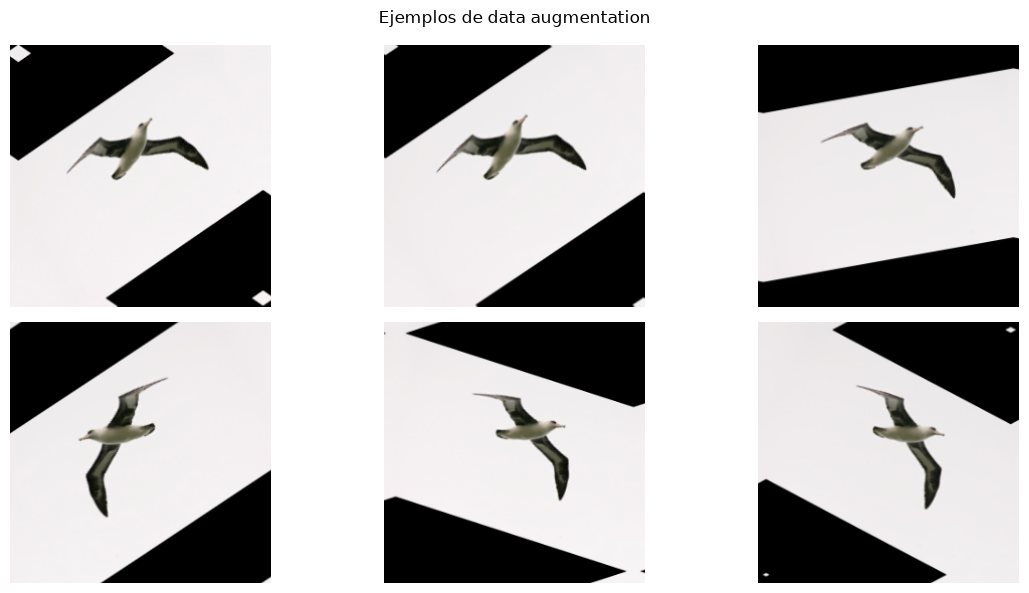

In [16]:
# Visualizamos varias versiones aumentadas de una misma imagen de entrenamiento.
for sample_image, _ in ds_train_raw.take(1):
    sample = tf.image.resize_with_pad(tf.cast(sample_image, tf.float32), IMG_SIZE, IMG_SIZE)

plt.figure(figsize=(12, 6))
for i in range(6):
    augmented = data_augmentation(tf.expand_dims(sample, 0), training=True)
    plt.subplot(2, 3, i + 1)
    plt.imshow(np.clip(augmented[0].numpy(), 0, 255).astype("uint8"))
    plt.axis("off")
plt.suptitle("Ejemplos de data augmentation")
plt.tight_layout()
plt.show()

## 6. Definir el modelo base


In [17]:
base_model = EfficientNetB2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# La data augmentation se enchufa solo en los modos que la usan (ver MODO).
if USAR_AUGMENTATION:
    x = data_augmentation(inputs)
else:
    x = inputs
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(DROPOUT_RATE)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs, name=f"EfficientNetB2_{MODO}")
model.summary()

Model: "EfficientNetB2_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 9, 9, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │       281,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,050,369 (30.71 MB)

 Trainable params: 281,800 (1.07 MB)

 Non-trainable params: 7,768,569 (29.63 MB)

## 7. Compilar y entrenar el modelo
Establecemos el `Algoritmo de Optimización`, la `Función de Coste` y las `metricas`


Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 79s 177ms/step - accuracy: 0.1437 - loss: 4.4965 - val_accuracy: 0.3253 - val_loss: 3.5224
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 51s 163ms/step - accuracy: 0.4225 - loss: 3.0281 - val_accuracy: 0.4512 - val_loss: 2.6829
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 49s 160ms/step - accuracy: 0.5531 - loss: 2.3223 - val_accuracy: 0.5196 - val_loss: 2.2355
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 50s 163ms/step - accuracy: 0.6344 - loss: 1.9156 - val_accuracy: 0.5563 - val_loss: 1.9729
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 49s 159ms/step - accuracy: 0.6801 - loss: 1.6463 - val_accuracy: 0.5730 - val_loss: 1.8046
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 50s 163ms/step - accuracy: 0.7143 - loss: 1.4403 - val_accuracy: 0.5988 - val_loss: 1.6986
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 49s 160ms/step - accuracy: 0.7491 - loss: 1.2861 - val_accuracy: 0.6097 - val_loss: 1.6049
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 51s 165ms/step - accuracy: 0.7606 - loss: 1

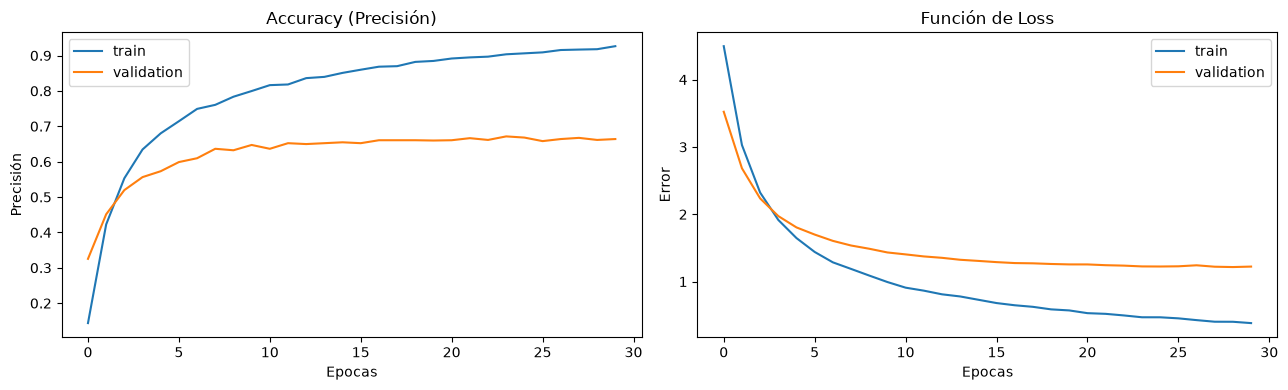

,accuracy,loss,val_accuracy,val_loss
0,0.143691,4.496451,0.325271,3.522428
1,0.422523,3.028144,0.451209,2.682854
2,0.553076,2.322267,0.519600,2.235456
3,0.634411,1.915618,0.556297,1.972882
4,0.680083,1.646255,0.572977,1.804606
5,0.714286,1.440337,0.598832,1.698587
6,0.749114,1.286091,0.609675,1.604936
7,0.760584,1.188405,0.636364,1.536051
8,0.783525,1.089683,0.632194,1.487973
9,0.799583,0.993545,0.647206,1.432784


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    #ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

history_df = plot_training_history(history)
display(history_df)


## 8. Fine-Tuning

Solo se ejecuta si `MODO == "finetuning"`. Partiendo de la cabeza ya entrenada en la fase 1, descongelamos el backbone (`base_model.trainable = True`) y volvemos a congelar las primeras `FINETUNE_FREEZE_LAYERS` capas, dejando entrenables solo las mas altas (de `block6` en adelante). Recompilamos con un learning rate bajo (`FINETUNE_LR`) y continuamos con `initial_epoch` para que las epocas sigan la numeracion de la fase 1.

Las capas `BatchNormalization` se mantienen en modo inferencia gracias al `training=False` con que llamamos al `base_model` en la celda 6, asi que no hace falta congelarlas una por una.

In [ ]:
if HACER_FINETUNING:
    # Descongelamos el base y volvemos a congelar las primeras N capas.
    base_model.trainable = True
    for layer in base_model.layers[:FINETUNE_FREEZE_LAYERS]:
        layer.trainable = False

    # con que llamamos al base en la celda 6, asi que no hace falta congelarlas a mano.
    model.compile(
        optimizer=Adam(learning_rate=FINETUNE_LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        initial_epoch=history.epoch[-1] + 1,
        epochs=history.epoch[-1] + 1 + FINETUNE_EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    plot_training_history(history_ft)


## 9. Evaluacion directa en conjunto de prueba


In [ ]:
test_metrics = model.evaluate(test_ds, verbose=1)

print("Metricas en conjunto de prueba:")
for name, value in zip(model.metrics_names, test_metrics):
    print(f"{name}: {value:.4f}")


## 10. Matriz de confusion y reporte de clasificacion


In [ ]:
# test_ds no esta barajado; asi y_true y y_pred quedan alineados.
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_pred = model.predict(test_ds, verbose=1).argmax(axis=1)

test_accuracy_from_predictions = np.mean(y_true == y_pred)
print(f"Accuracy en test ({model.name}): {test_accuracy_from_predictions:.4f}")

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).transpose()
display(report_df)


In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="viridis")
plt.title(f"Matriz de confusion - {model.name} ({len(class_names)} clases)")
plt.xlabel("Prediccion")
plt.ylabel("Clase real")
plt.colorbar()
plt.tight_layout()
plt.show()

cm_sin_diagonal = cm.copy()
np.fill_diagonal(cm_sin_diagonal, 0)

pares_confundidos = [
    (cm_sin_diagonal[i, j], i, j)
    for i in range(len(cm_sin_diagonal))
    for j in range(len(cm_sin_diagonal))
    if cm_sin_diagonal[i, j] > 0
]
pares_confundidos.sort(reverse=True)

print("Top 10 pares mas confundidos:")
for cantidad, real_idx, pred_idx in pares_confundidos[:10]:
    print(f"  '{class_names[real_idx]}' confundida con '{class_names[pred_idx]}': {cantidad} veces")


## 10.b Diccionario indice -> clase

Construimos un diccionario `idx_to_class` que mapea cada entero a su nombre de clase para saber a que especie corresponde cada indice. Esta celda **no depende del modelo entrenado**: usa `class_names` (definido al cargar el dataset) y `pares_confundidos` (de la matriz de confusion), por lo que se puede ejecutar sin volver a correr el entrenamiento.

In [ ]:
# Diccionario indice -> nombre de clase para interpretar los enteros de la matriz de confusion.
# Solo depende de `class_names` y `pares_confundidos`, por lo que se puede correr sin reentrenar.
idx_to_class = dict(enumerate(class_names))

# Nos quedamos con las clases que aparecen en el top de pares mas confundidos.
top_n = 10
indices_confundidos = sorted(
    {i for _, real_idx, pred_idx in pares_confundidos[:top_n] for i in (real_idx, pred_idx)}
)
clases_confundidas = {idx: idx_to_class[idx] for idx in indices_confundidos}

print(f"Clases involucradas en el top {top_n} de pares confundidos:")
for idx, nombre in clases_confundidas.items():
    print(f"  {idx}: {nombre}")


## 11. Guardar resultados y modelo


In [ ]:
# History completo: fase 1 (+ fase 2 de fine-tuning si corresponde).
frames = [pd.DataFrame(history.history)]
if HACER_FINETUNING:
    frames.append(pd.DataFrame(history_ft.history))
history_full_df = pd.concat(frames, ignore_index=True)

results = {
    "modelo": "EfficientNetB2",
    "modo": MODO,
    "dataset": DATASET_NAME,
    "train_split": TRAIN_SPLIT,
    "val_split": VAL_SPLIT,
    "test_split": TEST_SPLIT,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "augmentation": USAR_AUGMENTATION,
    "epochs_configuradas": EPOCHS,
    "epochs_ejecutadas": len(history_full_df),
    "learning_rate": LEARNING_RATE,
    "finetune_lr": FINETUNE_LR if HACER_FINETUNING else None,
    "finetune_freeze_layers": FINETUNE_FREEZE_LAYERS if HACER_FINETUNING else None,
    "test_loss": test_metrics[0],
    "test_accuracy": test_metrics[1],
}

results_df = pd.DataFrame([results])
display(results_df)

results_path = RESULTS_DIR / f"efficientnetb2_{MODO}_results.csv"
history_path = RESULTS_DIR / f"efficientnetb2_{MODO}_history.csv"
preds_path = RESULTS_DIR / f"efficientnetb2_{MODO}_preds.csv"
model_path = MODELS_DIR / f"efficientnetb2_{MODO}.keras"

results_df.to_csv(results_path, index=False)
history_full_df.to_csv(history_path, index=False)
# Predicciones por muestra del test: con esto se regenera la matriz de confusion,
# el reporte por clase y los pares confundidos sin volver a correr el modelo.
pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).to_csv(preds_path, index=False)
model.save(model_path)

# class_names es el mismo para todas las corridas; lo guardamos una sola vez para
# que el notebook de comparacion pueda etiquetar las clases sin cargar tfds.
class_names_path = RESULTS_DIR / "class_names.csv"
if not class_names_path.exists():
    pd.DataFrame({"idx": range(len(class_names)), "clase": class_names}).to_csv(
        class_names_path, index=False
    )

print("Resultados guardados en:", results_path)
print("History guardado en:", history_path)
print("Predicciones guardadas en:", preds_path)
print("Modelo guardado en:", model_path)